In [1]:
import pandas as pd

from datasets import load_dataset
import matplotlib.pyplot as plt

In [2]:
forget = pd.read_csv('/home/praveen/theoden/emnlp25/dpo_forget_idk.csv')
retain = pd.read_csv('/home/praveen/theoden/emnlp25/full_retain_qa.csv')

In [3]:
forget['type'] = 'forget'
forget = forget[['title', 'question', 'answer', 'type']]
forget['text'] = forget['question'] + ' ' + forget['answer']
retain['text'] = retain['question'] + ' ' + retain['answer']

df = pd.concat([forget, retain], ignore_index=True)


In [4]:
from sentence_transformers import SentenceTransformer

In [5]:
model = SentenceTransformer("all-MiniLM-L6-v2")

In [6]:
texts = df["text"].tolist()

In [7]:
embeddings = model.encode(texts, show_progress_bar=True)

Batches:   0%|          | 0/60 [00:00<?, ?it/s]

In [8]:
from xpysom import XPySom

In [9]:
xdim, ydim, dim = 6, 6, embeddings.shape[1]
som = XPySom(xdim, ydim, dim,
             sigma=0.3,
             learning_rate=0.5)

In [10]:
som.train(embeddings, 100)

In [11]:
bmus = [som.winner(vec) for vec in embeddings]
# bmus is a list of (i,j) coordinates on the 6×6 grid
df["som_bmu"] = bmus

print(df[["text", "som_bmu"]].head())

                                                text som_bmu
0     What nationality was Benedetto Varchi? Italian  (5, 1)
1  What professions did Benedetto Varchi have? Hu...  (2, 4)
2          Where was Benedetto Varchi born? Florence  (5, 1)
3  Who commissioned Benedetto Varchi to write a h...  (5, 1)
4  When was Varchi's Storia fiorentina first publ...  (5, 1)


In [12]:
df['title'].nunique()

79

In [13]:
forget_titles = df[df['type'] == 'forget']['title'].unique()
print(forget_titles)

['Benedetto Varchi' 'Wilhelm Wattenbach' 'Elsa Triolet' 'Theopompus'
 'Heinrich Ritter' 'Adrienne Monnier' 'Ann Brashares' 'Hartmann von Aue'
 'Jorge Semprún' 'Giovanni Battista Casti' 'Najaf Daryabandari'
 'Heinz Erhardt' 'Rudolf Christoph Eucken' 'Paul Gerhardt'
 'Moshe Greenberg' 'Amy Clampitt' 'Ted Kooser' 'Alfred Vogel'
 'Siegfried Lenz' 'Philip Stanhope, 5th Earl Stanhope']


In [14]:
#unique_titles = df['title'].unique()
title_to_index = {i: title for i, title in enumerate(forget_titles)}
print(title_to_index)

{0: 'Benedetto Varchi', 1: 'Wilhelm Wattenbach', 2: 'Elsa Triolet', 3: 'Theopompus', 4: 'Heinrich Ritter', 5: 'Adrienne Monnier', 6: 'Ann Brashares', 7: 'Hartmann von Aue', 8: 'Jorge Semprún', 9: 'Giovanni Battista Casti', 10: 'Najaf Daryabandari', 11: 'Heinz Erhardt', 12: 'Rudolf Christoph Eucken', 13: 'Paul Gerhardt', 14: 'Moshe Greenberg', 15: 'Amy Clampitt', 16: 'Ted Kooser', 17: 'Alfred Vogel', 18: 'Siegfried Lenz', 19: 'Philip Stanhope, 5th Earl Stanhope'}


In [15]:
df2 = df[df['title'].isin(forget_titles)]

In [16]:
print("Unique titles in df['title']:", df2['title'].unique())
print("title_to_index dictionary:", title_to_index)

# Create a dictionary to map titles to indices
index_by_title = {title: index for index, title in title_to_index.items()}

y = [index_by_title[title] for title in df2['title']]

from matplotlib.patches import Patch
import matplotlib.cm as cm
import numpy as np

# Generate a list of colors using a colormap
colors = cm.viridis(np.linspace(0, 1, len(title_to_index)))

legend_elements = [Patch(facecolor=colors[index], edgecolor='white', label=title)
                   for index, title in title_to_index.items()]

Unique titles in df['title']: ['Benedetto Varchi' 'Wilhelm Wattenbach' 'Elsa Triolet' 'Theopompus'
 'Heinrich Ritter' 'Adrienne Monnier' 'Ann Brashares' 'Hartmann von Aue'
 'Jorge Semprún' 'Giovanni Battista Casti' 'Najaf Daryabandari'
 'Heinz Erhardt' 'Rudolf Christoph Eucken' 'Paul Gerhardt'
 'Moshe Greenberg' 'Amy Clampitt' 'Ted Kooser' 'Alfred Vogel'
 'Siegfried Lenz' 'Philip Stanhope, 5th Earl Stanhope']
title_to_index dictionary: {0: 'Benedetto Varchi', 1: 'Wilhelm Wattenbach', 2: 'Elsa Triolet', 3: 'Theopompus', 4: 'Heinrich Ritter', 5: 'Adrienne Monnier', 6: 'Ann Brashares', 7: 'Hartmann von Aue', 8: 'Jorge Semprún', 9: 'Giovanni Battista Casti', 10: 'Najaf Daryabandari', 11: 'Heinz Erhardt', 12: 'Rudolf Christoph Eucken', 13: 'Paul Gerhardt', 14: 'Moshe Greenberg', 15: 'Amy Clampitt', 16: 'Ted Kooser', 17: 'Alfred Vogel', 18: 'Siegfried Lenz', 19: 'Philip Stanhope, 5th Earl Stanhope'}


In [17]:
df_forget = df2[df2['type'] == 'forget']

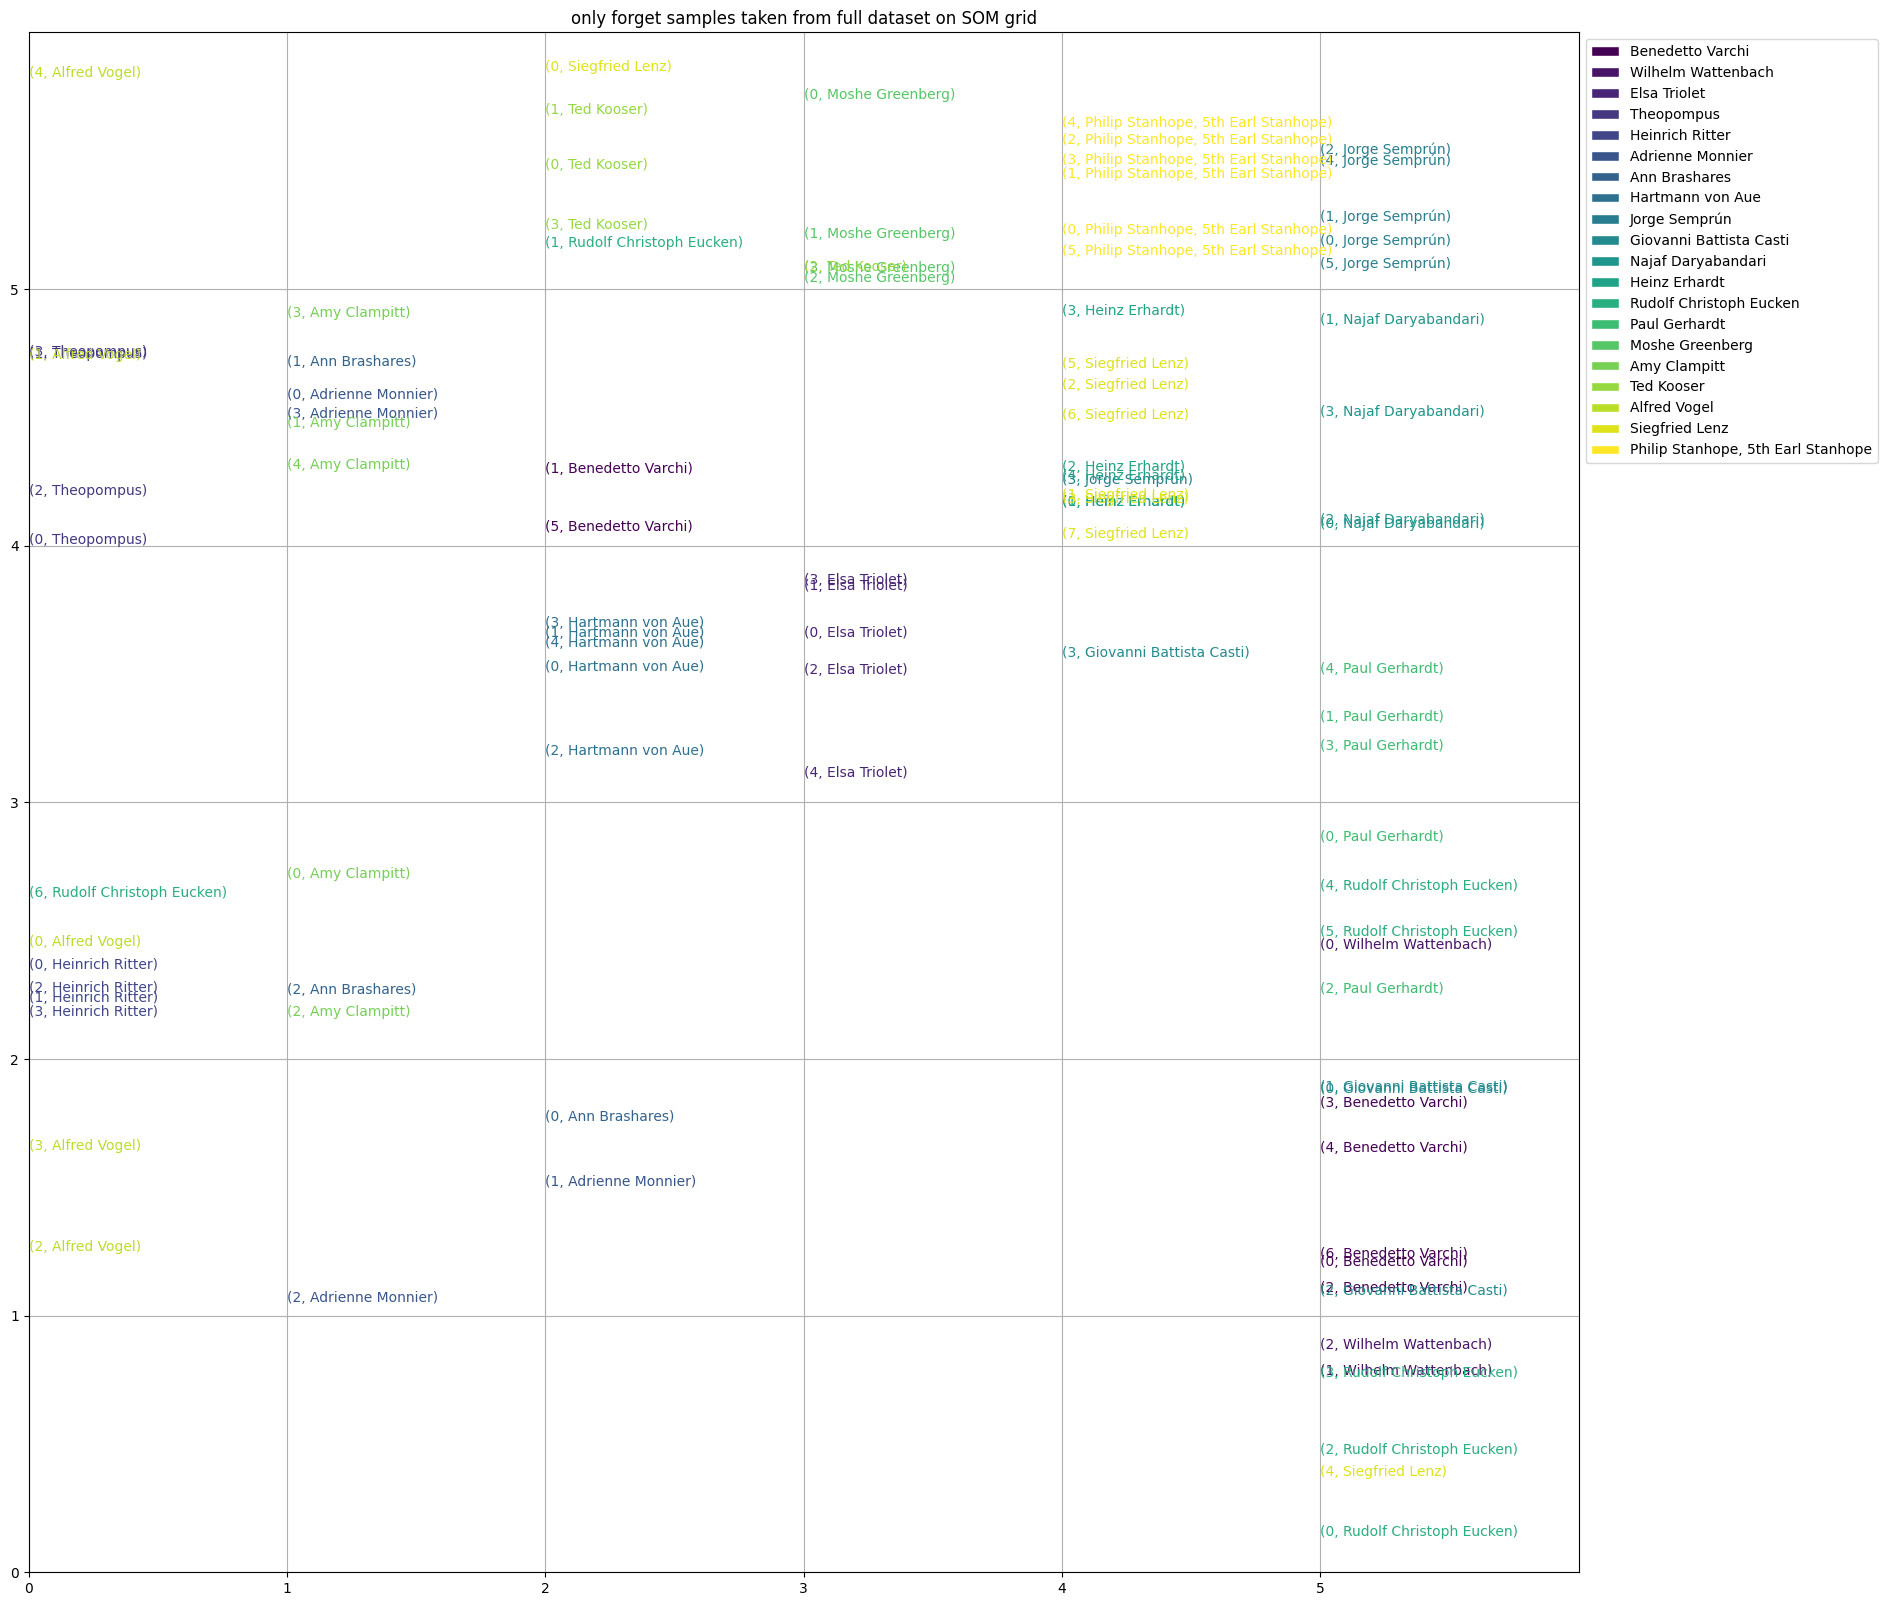

In [18]:
map_dim = 16

plt.figure(figsize=(20, 20))
texts_on_som = []

# Create a way to track the index of each question within its title group
title_question_counts = {}

for i, row in df_forget.iterrows():
    title = row['title']
    text = row['text']
    bmu = row['som_bmu']
    title_index = y[i] # Get the title index for coloring

    # Get the question index within this title group
    if title not in title_question_counts:
        title_question_counts[title] = 0
    else:
        title_question_counts[title] += 1
    question_index = title_question_counts[title]

    # Create the new label format: (question_index, Title Abbreviation)
    # Using the full title for now, abbreviation can be added later if needed
    label = f"({question_index}, {title})"

    # Use the bmu coordinates for placing the text
    texts_on_som.append(plt.text(bmu[0],
                                 bmu[1] + np.random.rand() * .9, # Add a small random offset to avoid overlapping texts
                                 label,
                                 color=colors[title_index])) # Use the generated colors based on title index

# Move the legend outside the plot
plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))
plt.xticks(range(xdim)) # Use xdim for x-axis ticks
plt.yticks(range(ydim)) # Use ydim for y-axis ticks
plt.grid()
plt.xlim([0, xdim]) # Set x-axis limits to SOM dimensions
plt.ylim([0, ydim]) # Set y-axis limits to SOM dimensions
plt.title("only forget samples taken from full dataset on SOM grid") # Add a title to the plot
plt.show() # Display the plot

In [19]:
df2['type'].unique()

array(['forget', 'domain', 'entity'], dtype=object)

In [20]:
df_retain = df2[df2['type'] != 'forget'].reset_index(drop=True)

In [21]:
df_retain['title'].unique()


array(['Adrienne Monnier', 'Alfred Vogel', 'Amy Clampitt',
       'Ann Brashares', 'Benedetto Varchi', 'Elsa Triolet',
       'Giovanni Battista Casti', 'Hartmann von Aue', 'Heinrich Ritter',
       'Heinz Erhardt', 'Jorge Semprún', 'Moshe Greenberg',
       'Najaf Daryabandari', 'Paul Gerhardt',
       'Philip Stanhope, 5th Earl Stanhope', 'Rudolf Christoph Eucken',
       'Siegfried Lenz', 'Ted Kooser', 'Theopompus', 'Wilhelm Wattenbach'],
      dtype=object)

In [22]:
df_forget['title'].unique()

array(['Benedetto Varchi', 'Wilhelm Wattenbach', 'Elsa Triolet',
       'Theopompus', 'Heinrich Ritter', 'Adrienne Monnier',
       'Ann Brashares', 'Hartmann von Aue', 'Jorge Semprún',
       'Giovanni Battista Casti', 'Najaf Daryabandari', 'Heinz Erhardt',
       'Rudolf Christoph Eucken', 'Paul Gerhardt', 'Moshe Greenberg',
       'Amy Clampitt', 'Ted Kooser', 'Alfred Vogel', 'Siegfried Lenz',
       'Philip Stanhope, 5th Earl Stanhope'], dtype=object)

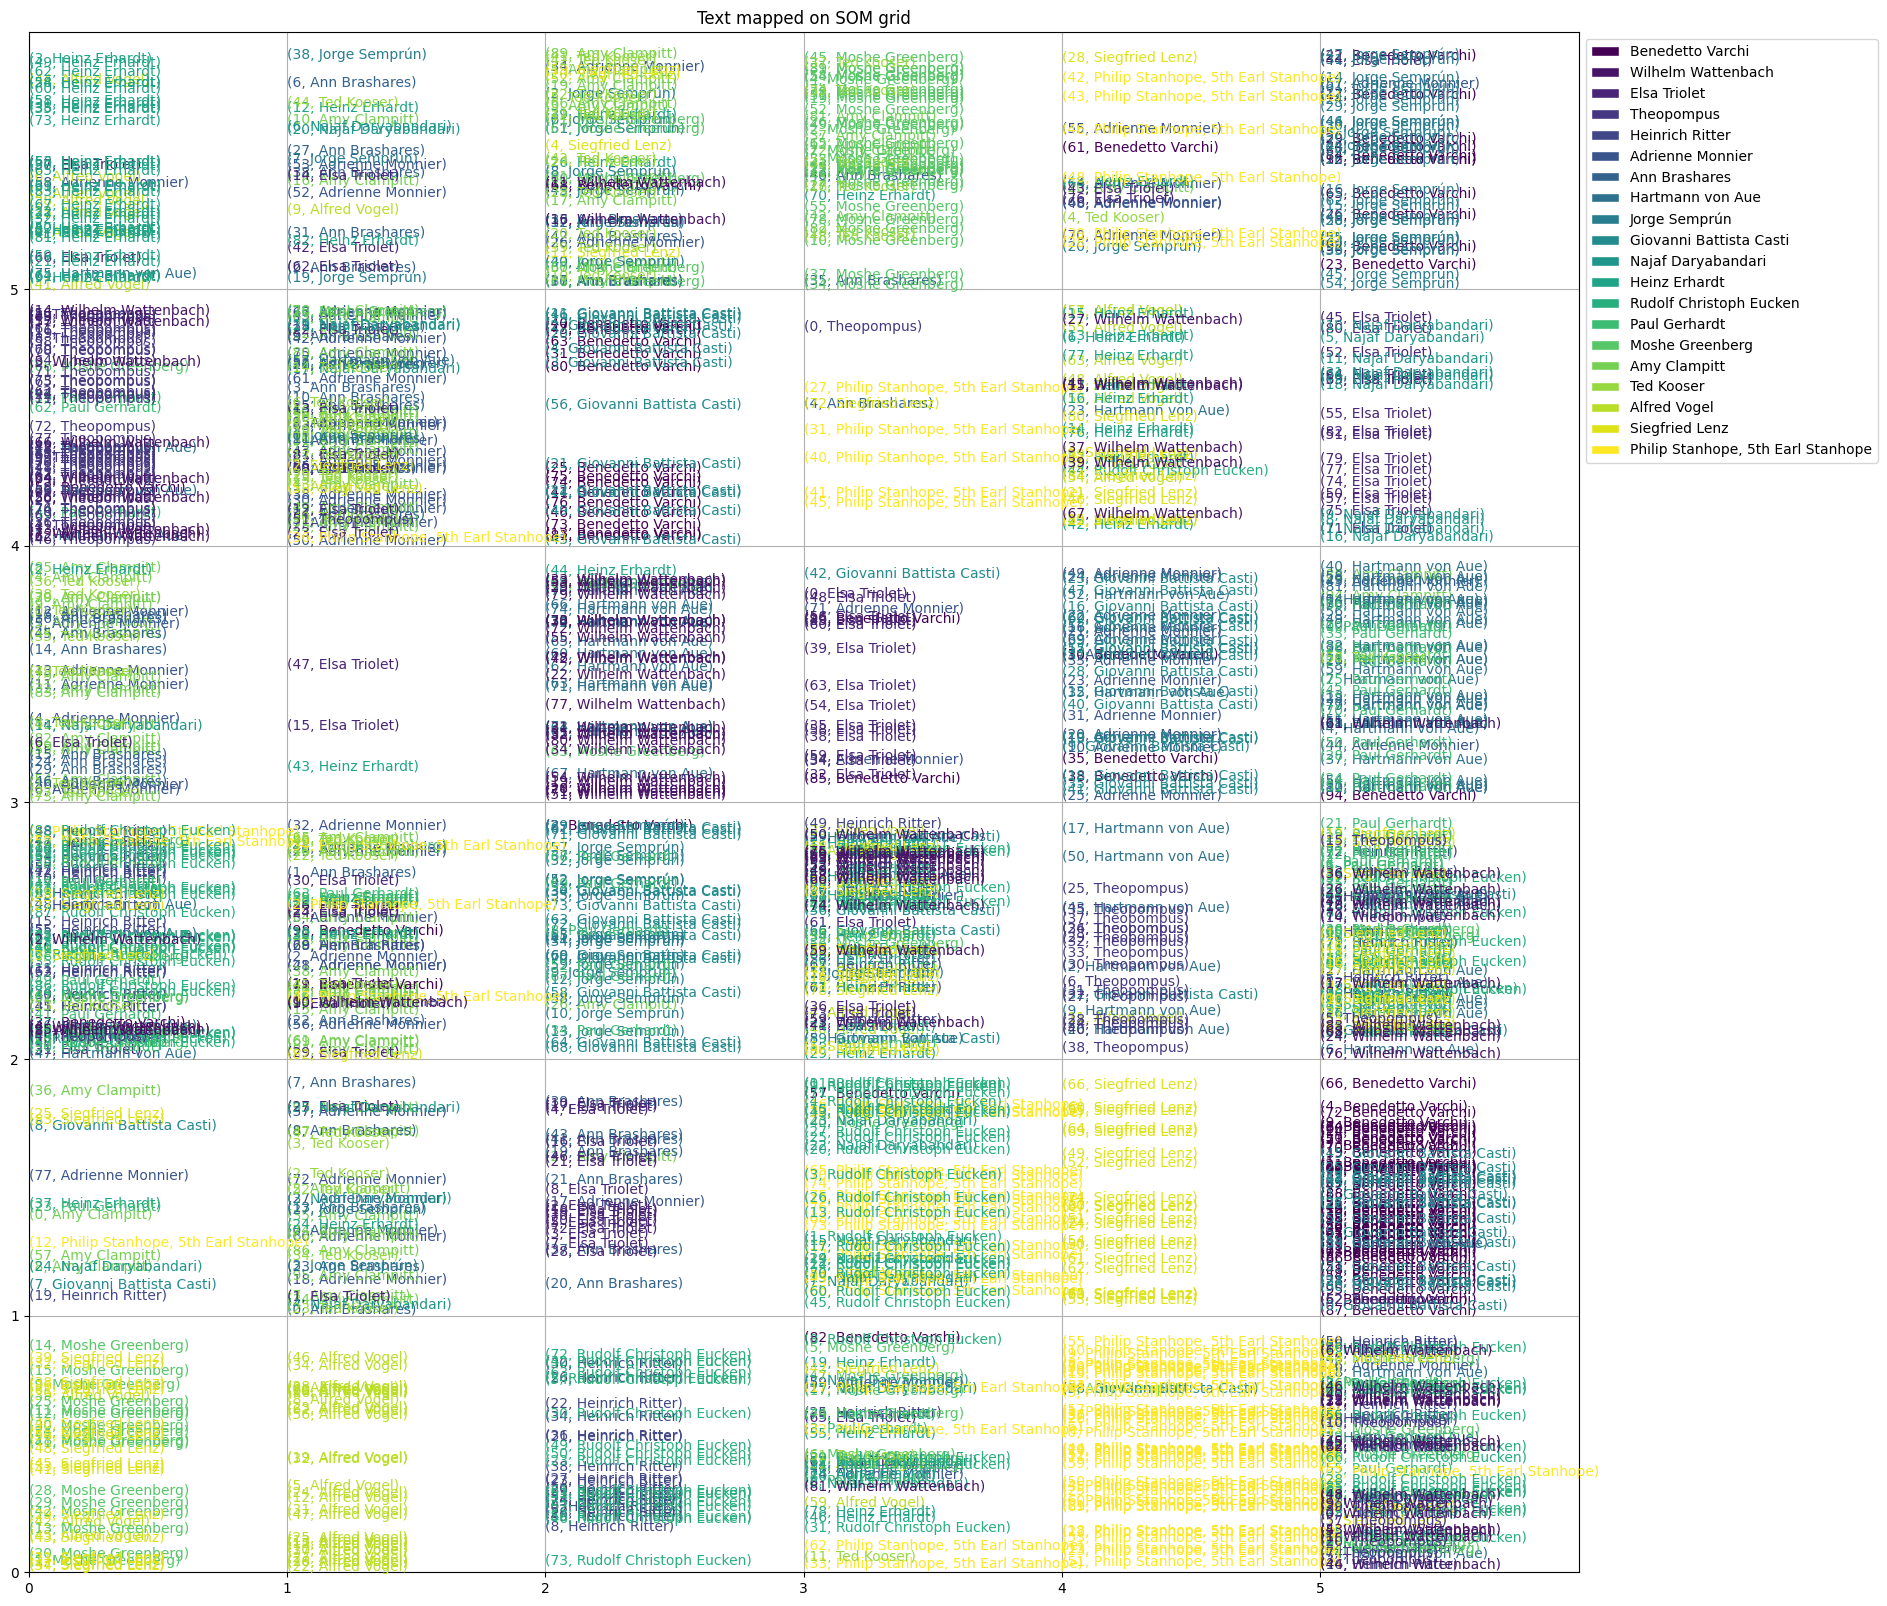

In [23]:
title_to_index = {title: idx for idx, title in enumerate(df2['title'].unique())}
colors = cm.viridis(np.linspace(0, 1, len(title_to_index)))

# 1. Filter rows but keep a clean index
df_retain = df2[df2['type'] != 'forget']

# 2. Plot
plt.figure(figsize=(20, 20))
title_question_counts = {}

for _, row in df_retain.iterrows():
    title = row['title']
    bmu   = row['som_bmu']
    idx   = title_to_index[title]          # <— robust

    # running count per title
    q_idx = title_question_counts.get(title, 0)
    title_question_counts[title] = q_idx + 1

    label = f"({q_idx}, {title})"
    plt.text(bmu[0],
             bmu[1] + np.random.rand() * .9,
             label,
             color=colors[idx])

# Legend
legend_elements = [
    Patch(facecolor=colors[idx], edgecolor='white', label=title)
    for title, idx in title_to_index.items()
]
plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))
plt.xticks(range(xdim))
plt.yticks(range(ydim))
plt.grid()
plt.xlim([0, xdim])
plt.ylim([0, ydim])
plt.title("Text mapped on SOM grid")
plt.show()

In [24]:
from sklearn.cluster import KMeans
import numpy as np

som_weights = som.get_weights()
som_weights_reshaped = som_weights.reshape(-1, dim)
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
neuron_cluster_labels = kmeans.fit_predict(som_weights_reshaped)
neuron_cluster_grid = neuron_cluster_labels.reshape(xdim, ydim)

print("Shape of SOM weights:", som_weights.shape)
print("Shape of reshaped SOM weights:", som_weights_reshaped.shape)
print("Shape of neuron cluster labels:", neuron_cluster_labels.shape)
print("Shape of neuron cluster grid:", neuron_cluster_grid.shape)

Shape of SOM weights: (6, 6, 384)
Shape of reshaped SOM weights: (36, 384)
Shape of neuron cluster labels: (36,)
Shape of neuron cluster grid: (6, 6)


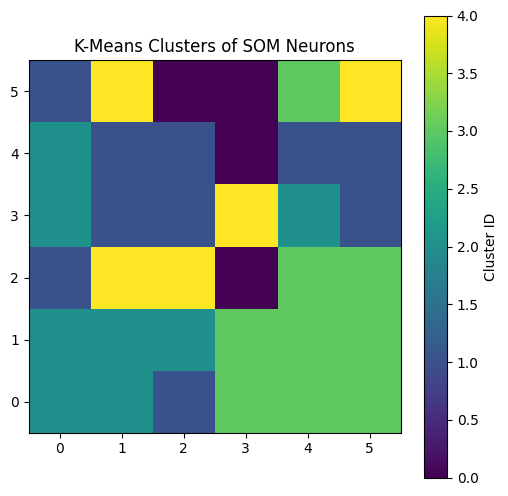

In [25]:
plt.figure(figsize=(xdim, ydim))
plt.imshow(neuron_cluster_grid, cmap='viridis', origin='lower')
plt.title("K-Means Clusters of SOM Neurons")
plt.xticks(np.arange(xdim))
plt.yticks(np.arange(ydim))
plt.colorbar(label='Cluster ID')
plt.grid(False)
plt.show()

In [27]:
# Calculate embeddings for the entire df DataFrame
df_embeddings = model.encode(df2['text'].tolist(), show_progress_bar=True)

# Calculate BMUs for the entire df DataFrame
df_bmus = [som.winner(vec) for vec in df_embeddings]

# Map each data point's BMU to its cluster ID
data_point_cluster_labels = []
for bmu in df_bmus:
    # bmu is a tuple (x, y)
    cluster_id = neuron_cluster_grid[bmu[0], bmu[1]]
    data_point_cluster_labels.append(cluster_id)

# Add the cluster labels to the DataFrame
df2['cluster_label'] = data_point_cluster_labels

# Prompt the user to enter a cluster ID
try:
    selected_cluster_id = int(input(f"Enter a cluster ID (0 to {n_clusters - 1}): "))
    if selected_cluster_id < 0 or selected_cluster_id >= n_clusters:
        print(f"Invalid cluster ID. Please enter a number between 0 and {n_clusters - 1}.")
    else:
        # Filter the DataFrame for the selected cluster
        cluster_data = df2[df2['cluster_label'] == selected_cluster_id]

        # Display the data for the selected cluster
        print(f"\nData points in Cluster {selected_cluster_id}:")
        display(cluster_data[['title', 'question', 'answer', 'type']])

except ValueError:
    print("Invalid input. Please enter an integer.")

Batches:   0%|          | 0/51 [00:00<?, ?it/s]

/tmp/ipykernel_2783159/1801638757.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['cluster_label'] = data_point_cluster_labels



Data points in Cluster 0:


,title,question,answer,type
7,Wilhelm Wattenbach,What nationality was Wilhelm Wattenbach?,German,forget
30,Hartmann von Aue,What was Hartmann von Aue's nationality?,German,forget
31,Hartmann von Aue,Name one of Hartmann von Aue's works.,Erec,forget
32,Hartmann von Aue,In which crusade did Hartmann von Aue particip...,The Crusade of 1197,forget
33,Hartmann von Aue,What was Hartmann von Aue's profession aside f...,Knight,forget
...,...,...,...,...
1877,Wilhelm Wattenbach,What was the significance of Heinrich von Sybe...,It was a work of great importance on German un...,domain
1878,Wilhelm Wattenbach,What was the title of Heinrich von Sybel's wor...,Die Begründung des deutschen Reiches durch Wil...,domain
1879,Wilhelm Wattenbach,What was the significance of Heinrich von Sybe...,It showed for the first time the connection be...,domain
1880,Wilhelm Wattenbach,What was the title of Heinrich von Sybel's maj...,Geschichte der Revolutionszeit 1789–1800,domain


In [29]:
df_retain = df2[df2['type'] != 'forget'].reset_index(drop=True)

In [30]:
# Group the df_retain DataFrame by cluster_label
grouped_retain = df_retain.groupby('cluster_label')

# Calculate the centroid for each cluster
cluster_centroids = {}
for cluster_label, group in grouped_retain:
    # Get the indices of the data points in the current cluster group from the original df
    original_indices = group.index

    # Select the corresponding embeddings using the original indices
    cluster_embeddings = df_embeddings[original_indices]

    # Calculate the mean of the embeddings to get the centroid
    centroid = np.mean(cluster_embeddings, axis=0)

    # Store the centroid
    cluster_centroids[cluster_label] = centroid

# Display the keys of the dictionary to show the calculated centroids per cluster
print("Calculated centroids for the following clusters:")
print(cluster_centroids.keys())

Calculated centroids for the following clusters:
dict_keys([0, 1, 2, 3, 4])


In [31]:
closest_points_retain = {}

for cluster_label, centroid in cluster_centroids.items():
    # Get the original indices from df that belong to this cluster
    original_cluster_indices = df2[df2['cluster_label'] == cluster_label].index

    # Filter these indices to keep only those that are also in df_retain's index
    retain_indices_in_cluster = original_cluster_indices.intersection(df_retain.index)

    # If there are no retain points in this cluster, skip
    if retain_indices_in_cluster.empty:
        closest_points_retain[cluster_label] = []
        continue

    # Select the corresponding embeddings for these retain data points from df_embeddings
    cluster_retain_embeddings = df_embeddings[retain_indices_in_cluster]

    # Calculate the Euclidean distance between each of these data point embeddings and the cluster's centroid
    # The centroid was calculated using all retain points in the cluster (in cluster_centroids)
    distances = np.linalg.norm(cluster_retain_embeddings - centroid, axis=1)

    # Get the original indices of these retain data points, sort them based on their calculated distances
    sorted_retain_indices = retain_indices_in_cluster[np.argsort(distances)]

    # Store the sorted original indices for the current cluster (only retain points)
    closest_points_retain[cluster_label] = sorted_retain_indices.tolist()

print("Original indices of RETAIN data points sorted by distance to cluster centroid for each cluster:")
for cluster_label, indices in closest_points_retain.items():
    print(f"Cluster {cluster_label}: {indices[:10]}...") 

Original indices of RETAIN data points sorted by distance to cluster centroid for each cluster:
Cluster 0: [1290, 662, 693, 31, 679, 757, 1310, 61, 33, 793]...
Cluster 1: [1355, 1309, 1262, 1226, 1455, 85, 772, 722, 1199, 1209]...
Cluster 2: [198, 201, 572, 1359, 1257, 1369, 694, 196, 1217, 193]...
Cluster 3: [562, 975, 1258, 733, 960, 74, 658, 1263, 424, 23]...
Cluster 4: [496, 490, 484, 27, 553, 2, 1062, 1063, 552, 24]...


In [33]:
def select_coreset(coreset_size, closest_points, df):
    """Selects a coreset of a specified size from each cluster."""
    coreset_indices = []
    for cluster_label, indices in closest_points.items():
        # Select the first coreset_size indices from the sorted list
        selected_indices = indices[:coreset_size]
        coreset_indices.extend(selected_indices)

    # Filter the original df DataFrame using the collected indices
    coreset_df = df2.loc[coreset_indices].copy()
    return coreset_df

# Select coreset of size 2 per cluster
coreset_df_size_2 = select_coreset(2, closest_points_retain, df2)
print(f"\nCoreset of size 2 per cluster:")
print(f"Size of coreset DataFrame: {coreset_df_size_2.shape}")
print("Head of coreset DataFrame:")
display(coreset_df_size_2[['title', 'question', 'answer', 'type', 'cluster_label']])

# Select coreset of size 3 per cluster
coreset_df_size_3 = select_coreset(3, closest_points_retain, df2)
print(f"\nCoreset of size 3 per cluster:")
print(f"Size of coreset DataFrame: {coreset_df_size_3.shape}")
print("Head of coreset DataFrame:")
display(coreset_df_size_3[['title', 'question', 'answer', 'type', 'cluster_label']])


# Select coreset of size 3 per cluster
coreset_df_size_5 = select_coreset(5, closest_points_retain, df2)
print(f"\nCoreset of size 5 per cluster:")
print(f"Size of coreset DataFrame: {coreset_df_size_5.shape}")
print("Head of coreset DataFrame:")
display(coreset_df_size_3[['title', 'question', 'answer', 'type', 'cluster_label']])


Coreset of size 2 per cluster:
Size of coreset DataFrame: (10, 7)
Head of coreset DataFrame:


,title,question,answer,type,cluster_label
1290,Paul Gerhardt,Who was the ruler that stipulated the creation...,John George I of Saxony,entity,0
662,Giovanni Battista Casti,Where was Christoph Willibald Gluck raised?,Bohemia,domain,0
1355,"Philip Stanhope, 5th Earl Stanhope",How many volumes did Introduction to the Liter...,Four volumes,domain,1
1309,Paul Gerhardt,What was the purpose of the Formula of Concord...,The purpose was the unification and preservati...,entity,1
198,Alfred Vogel,When did Heinrich Mann marry his first wife?,1914,domain,2
201,Alfred Vogel,When did Heinrich Mann die?,"March 11, 1950",domain,2
562,Elsa Triolet,Who played Colette in the 1991 film Becoming C...,Mathilda May,domain,3
975,Heinz Erhardt,How many books has Harald Schmidt published?,More than 10,domain,3
496,Benedetto Varchi,Where did Giovanni Boccaccio grow up?,Florence,domain,4
490,Benedetto Varchi,Where is Giovanni Boccaccio buried?,Certaldo,domain,4



Coreset of size 3 per cluster:
Size of coreset DataFrame: (15, 7)
Head of coreset DataFrame:


,title,question,answer,type,cluster_label
1290,Paul Gerhardt,Who was the ruler that stipulated the creation...,John George I of Saxony,entity,0
662,Giovanni Battista Casti,Where was Christoph Willibald Gluck raised?,Bohemia,domain,0
693,Giovanni Battista Casti,Where was the first performance of Prima la mu...,Orangery of the Schönbrunn Palace in Vienna,entity,0
1355,"Philip Stanhope, 5th Earl Stanhope",How many volumes did Introduction to the Liter...,Four volumes,domain,1
1309,Paul Gerhardt,What was the purpose of the Formula of Concord...,The purpose was the unification and preservati...,entity,1
1262,Najaf Daryabandari,What was the name of Sadegh Hedayat's most end...,The Blind Owl,domain,1
198,Alfred Vogel,When did Heinrich Mann marry his first wife?,1914,domain,2
201,Alfred Vogel,When did Heinrich Mann die?,"March 11, 1950",domain,2
572,Elsa Triolet,What was the pen name used by Colette's first ...,Willy,domain,2
562,Elsa Triolet,Who played Colette in the 1991 film Becoming C...,Mathilda May,domain,3



Coreset of size 5 per cluster:
Size of coreset DataFrame: (25, 7)
Head of coreset DataFrame:


,title,question,answer,type,cluster_label
1290,Paul Gerhardt,Who was the ruler that stipulated the creation...,John George I of Saxony,entity,0
662,Giovanni Battista Casti,Where was Christoph Willibald Gluck raised?,Bohemia,domain,0
693,Giovanni Battista Casti,Where was the first performance of Prima la mu...,Orangery of the Schönbrunn Palace in Vienna,entity,0
1355,"Philip Stanhope, 5th Earl Stanhope",How many volumes did Introduction to the Liter...,Four volumes,domain,1
1309,Paul Gerhardt,What was the purpose of the Formula of Concord...,The purpose was the unification and preservati...,entity,1
1262,Najaf Daryabandari,What was the name of Sadegh Hedayat's most end...,The Blind Owl,domain,1
198,Alfred Vogel,When did Heinrich Mann marry his first wife?,1914,domain,2
201,Alfred Vogel,When did Heinrich Mann die?,"March 11, 1950",domain,2
572,Elsa Triolet,What was the pen name used by Colette's first ...,Willy,domain,2
562,Elsa Triolet,Who played Colette in the 1991 film Becoming C...,Mathilda May,domain,3


In [34]:
# Determine the target coreset size
num_retain = len(df_retain)
num_forget = len(forget)

target_coreset_size_percentage = int(num_retain * 0.10)
target_coreset_size = max(target_coreset_size_percentage, num_forget)

print(f"Total retain data points: {num_retain}")
print(f"Total forget data points: {num_forget}")
print(f"10% of retain data points: {target_coreset_size_percentage}")
print(f"Target coreset size (max of 10% retain or forget size): {target_coreset_size}")

# Distribute the target coreset size across clusters
# We will aim for proportional distribution, ensuring at least 1 from each cluster if possible
num_clusters = len(closest_points_retain) # Use the number of clusters with retain points
allocated_sizes = {}
remaining_to_allocate = target_coreset_size - num_clusters # Allocate at least 1 to each cluster initially

if remaining_to_allocate < 0:
    print("\nWarning: Target coreset size is smaller than the number of clusters with retain points. Selecting one retain point from each cluster.")
    for cluster_label in closest_points_retain.keys():
        allocated_sizes[cluster_label] = 1
else:
    total_retain_in_clusters = sum(len(indices) for indices in closest_points_retain.values())
    if total_retain_in_clusters == 0:
        print("\nError: No retain data points found in clusters.")
        allocated_sizes = {cluster_label: 0 for cluster_label in closest_points_retain.keys()}
    else:
        for cluster_label, indices in closest_points_retain.items():
            # Proportional allocation based on number of retain points in cluster
            proportion = len(indices) / total_retain_in_clusters
            allocated_sizes[cluster_label] = 1 + int(proportion * remaining_to_allocate)

# Adjust if sum exceeds target or if any cluster got less than 1 (due to rounding)
# Add remaining points to the clusters with the most available retain points
while sum(allocated_sizes.values()) < target_coreset_size:
    # Find clusters that still have available points to allocate
    available_clusters = [cl for cl in allocated_sizes.keys() if allocated_sizes[cl] < len(closest_points_retain[cl])]
    if not available_clusters:
        print("\nWarning: Cannot allocate more points, all available retain points have been selected.")
        break
    # Find the cluster among available ones with the most allocated size currently (to prioritize larger clusters)
    largest_available_cluster = max(available_clusters, key=allocated_sizes.get)
    allocated_sizes[largest_available_cluster] += 1


# Ensure no cluster allocation exceeds the number of retain points available in that cluster
for cluster_label, size in allocated_sizes.items():
    allocated_sizes[cluster_label] = min(size, len(closest_points_retain[cluster_label]))

print("\nAllocated coreset size per cluster:", allocated_sizes)
print("Total allocated size:", sum(allocated_sizes.values()))


# Select coreset based on allocated sizes and closest points (from retain only)
coreset_indices = []
for cluster_label, size in allocated_sizes.items():
    # Select the first 'size' original indices from the sorted list of closest RETAIN points
    selected_indices = closest_points_retain[cluster_label][:size]
    coreset_indices.extend(selected_indices)

# Filter the original df DataFrame using the collected indices
# Ensure only 'retain' samples are included by filtering df_retain
coreset_df = df_retain.loc[coreset_indices].copy()


print(f"\nFinal coreset size: {len(coreset_df)}")
print("Head of the selected coreset:")
display(coreset_df[['title', 'question', 'answer', 'type', 'cluster_label']])

Total retain data points: 1508
Total forget data points: 98
10% of retain data points: 150
Target coreset size (max of 10% retain or forget size): 150

Allocated coreset size per cluster: {0: 21, 1: 43, 2: 27, 3: 33, 4: 26}
Total allocated size: 150

Final coreset size: 150
Head of the selected coreset:


,title,question,answer,type,cluster_label
1290,Siegfried Lenz,What was the original purpose of the German au...,It was originally conceived as the cargo ship ...,entity,1
662,Heinrich Ritter,What was the name of Schopenhauer's mother?,Johanna Schopenhauer,domain,1
693,Heinrich Ritter,In which German state is Zerbst located?,Saxony-Anhalt,entity,1
31,Adrienne Monnier,What was the title of T.S. Eliot's play that w...,Cats,domain,0
679,Heinrich Ritter,What was Zerbst's administrative status before...,Capital of the former Anhalt-Zerbst district,entity,1
...,...,...,...,...,...
485,Giovanni Battista Casti,Who were Alessandro Scarlatti's children who w...,Domenico Scarlatti and Pietro Filippo Scarlatti,domain,4
1058,"Philip Stanhope, 5th Earl Stanhope",What was Thomas Babington Macaulay's role in d...,He played a substantial role in introducing We...,domain,2
729,Heinz Erhardt,What was the name of the German film version r...,Catweazle,domain,3
14,Adrienne Monnier,When was T.S. Eliot born?,26 September 1888,domain,2


In [35]:
coreset_df.head()

,title,question,answer,type,text,som_bmu,cluster_label
1290,Siegfried Lenz,What was the original purpose of the German au...,It was originally conceived as the cargo ship ...,entity,What was the original purpose of the German au...,"(3, 2)",1
662,Heinrich Ritter,What was the name of Schopenhauer's mother?,Johanna Schopenhauer,domain,What was the name of Schopenhauer's mother? Jo...,"(2, 0)",1
693,Heinrich Ritter,In which German state is Zerbst located?,Saxony-Anhalt,entity,In which German state is Zerbst located? Saxon...,"(3, 2)",1
31,Adrienne Monnier,What was the title of T.S. Eliot's play that w...,Cats,domain,What was the title of T.S. Eliot's play that w...,"(4, 3)",0
679,Heinrich Ritter,What was Zerbst's administrative status before...,Capital of the former Anhalt-Zerbst district,entity,What was Zerbst's administrative status before...,"(3, 2)",1


In [36]:
coreset_df.to_csv('coreset_10.csv', index = False)

In [37]:
coreset_df['type'].value_counts(normalize = True)

type
domain    0.693333
entity    0.306667
Name: proportion, dtype: float64

In [ ]:
coreset_df